# Exploring the Relationship Between Trader Performance and Market Sentiment

## Table of Contents

1. Import Required Libraries
2. Load the Datasets
3. Data Inspection
4. Data Preprocessing
5. Dataset Integration
6. Exploratory Data Analysis
7. Statistical Validation
8. Hidden Pattern Discovery
9. Data Visualization
10. Key Findings and Business Insights

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, shapiro

sns.set_style("whitegrid")

In [ ]:
history = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

/tmp/ipykernel_1658/2133195012.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  history = pd.read_csv("historical_data.csv")


In [ ]:
print("Historical Data")
display(history.head())

print(history.info())

print("\nFear Greed Data")
display(sentiment.head())

print(sentiment.info())

Historical Data


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83805 entries, 0 to 83804
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           83805 non-null  object 
 1   Coin              83805 non-null  object 
 2   Execution Price   83805 non-null  float64
 3   Size Tokens       83805 non-null  float64
 4   Size USD          83805 non-null  float64
 5   Side              83805 non-null  object 
 6   Timestamp IST     83805 non-null  object 
 7   Start Position    83805 non-null  float64
 8   Direction         83805 non-null  object 
 9   Closed PnL        83805 non-null  float64
 10  Transaction Hash  83805 non-null  object 
 11  Order ID          83804 non-null  float64
 12  Crossed           83804 non-null  object 
 13  Fee               83804 non-null  float64
 14  Trade ID          83804 non-null  float64
 15  Timestamp         83804 non-null  float64
dtypes: float64(9), object(7)
memory usage: 1

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [ ]:
print(history.columns.tolist())
print(sentiment.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
['timestamp', 'value', 'classification', 'date']


In [ ]:
# Remove rows with missing important values

history = history.dropna(subset=[
    "Timestamp IST",
    "Closed PnL",
    "Size USD",
    "Fee"
])

history.reset_index(drop=True, inplace=True)

In [ ]:
# Convert trading timestamp to datetime

history["Timestamp IST"] = pd.to_datetime(
    history["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Keep only the date

history["date"] = history["Timestamp IST"].dt.date

# Convert sentiment date

sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

In [ ]:
merged = pd.merge(
    history,
    sentiment,
    on="date",
    how="inner"
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (83798, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [ ]:
print(merged.columns)

print()

print(merged[[
    "date",
    "classification",
    "value",
    "Closed PnL"
]].head())

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'timestamp', 'value', 'classification'],
      dtype='object')

         date classification  value  Closed PnL
0  2024-12-02  Extreme Greed     80         0.0
1  2024-12-02  Extreme Greed     80         0.0
2  2024-12-02  Extreme Greed     80         0.0
3  2024-12-02  Extreme Greed     80         0.0
4  2024-12-02  Extreme Greed     80         0.0


In [ ]:
summary = merged.groupby("classification").agg(
    Trades=("Closed PnL", "count"),
    Avg_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Std_PnL=("Closed PnL", "std"),
    Avg_Size_USD=("Size USD", "mean"),
    Avg_Fee=("Fee", "mean")
)

summary = summary.round(2)

summary

,Trades,Avg_PnL,Median_PnL,Std_PnL,Avg_Size_USD,Avg_Fee
classification,,,,,,
Extreme Fear,7172,87.44,0.00,1775.07,5400.53,0.94
Extreme Greed,10711,155.32,0.85,1385.25,7354.07,1.75
Fear,30401,82.17,0.00,1247.54,10877.41,1.87
Greed,19586,79.75,0.00,1402.32,11519.40,2.57
Neutral,15928,71.85,0.00,717.11,8017.05,1.73


In [ ]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = (
    merged.groupby("classification")["Win"]
    .mean()
    .mul(100)
    .round(2)
)

win_rate

,Win
classification,
Extreme Fear,38.02
Extreme Greed,53.86
Fear,45.79
Greed,40.29
Neutral,46.53


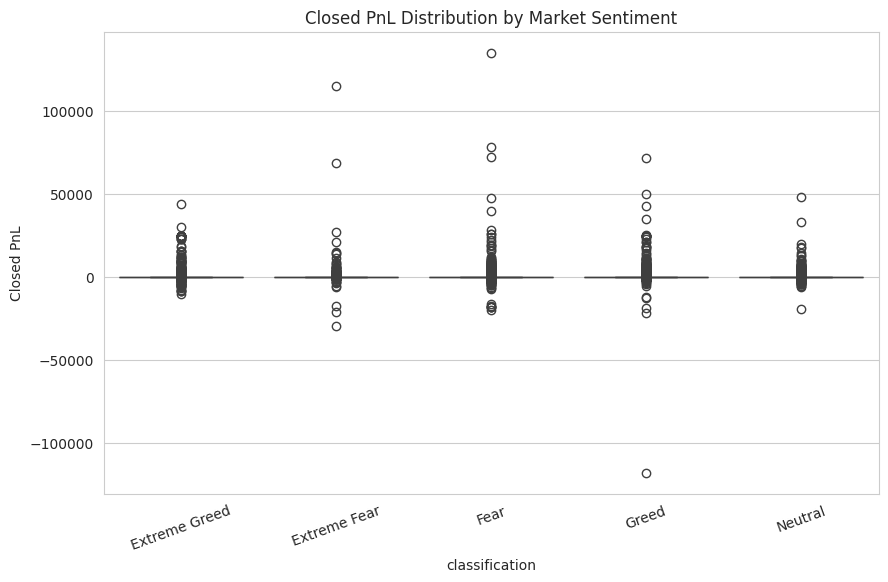

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="classification",
    y="Closed PnL",
    data=merged
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xticks(rotation=20)

plt.show()

In [ ]:
from scipy.stats import shapiro

sample = merged[merged["classification"]=="Greed"]["Closed PnL"]

sample = sample.sample(5000, random_state=42)

stat,p = shapiro(sample)

print(stat,p)

0.028512681140863583 3.6131520354533156e-95


In [ ]:
fear = merged.loc[
    merged["classification"]=="Fear",
    "Closed PnL"
]

greed = merged.loc[
    merged["classification"]=="Greed",
    "Closed PnL"
]

neutral = merged.loc[
    merged["classification"]=="Neutral",
    "Closed PnL"
]

extreme_fear = merged.loc[
    merged["classification"]=="Extreme Fear",
    "Closed PnL"
]

extreme_greed = merged.loc[
    merged["classification"]=="Extreme Greed",
    "Closed PnL"]

stat,p = kruskal(
    fear,
    greed,
    neutral,
    extreme_fear,
    extreme_greed
)

print("Statistic =",stat)
print("P-value =",p)

Statistic = 836.4495589056418
P-value = 9.766366847321983e-180


In [ ]:
merged[["Closed PnL","value"]].corr()

,Closed PnL,value
Closed PnL,1.000000,0.015388
value,0.015388,1.000000


In [ ]:
coin_summary = (
    merged
    .groupby(["classification","Coin"])
    ["Closed PnL"]
    .mean()
    .reset_index()
)

coin_summary

,classification,Coin,Closed PnL
0,Extreme Fear,@107,-23.660073
1,Extreme Fear,@142,28.525128
2,Extreme Fear,@4,-13.810710
3,Extreme Fear,@51,0.000000
4,Extreme Fear,@8,1.432312
...,...,...,...
382,Neutral,VVV,15.950143
383,Neutral,WIF,0.000000
384,Neutral,ZEREBRO,12.286535
385,Neutral,ZETA,-1.542643


In [ ]:
merged.groupby(
    ["classification","Side"]
)["Closed PnL"].mean()

classification  Side
Extreme Fear    BUY      69.934185
                SELL    112.412140
Extreme Greed   BUY      30.009239
                SELL    254.423168
Fear            BUY      98.385120
                SELL     66.278019
Greed           BUY      60.367304
                SELL     96.781339
Neutral         BUY      75.205968
                SELL     68.301590
Name: Closed PnL, dtype: float64

In [ ]:
top_traders = (
    merged
    .groupby("Account")
    .agg(
        Trades=("Closed PnL","count"),
        AvgPnL=("Closed PnL","mean"),
        TotalPnL=("Closed PnL","sum")
    )
)

top_traders.sort_values(
    "TotalPnL",
    ascending=False
).head(20)

,Trades,AvgPnL,TotalPnL
Account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,145.481748,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,419.127768,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,44.364091,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,68.684419,8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,1237,336.735548,4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,38.319560,3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,253.187858,3.605395e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760,7584,40.740489,3.089759e+05
0x420ab45e0bd8863569a5efbb9c05d91f40624641,383,520.902331,1.995056e+05


In [ ]:
trader_sentiment = (
    merged.groupby(
        ["Account","classification"]
    )["Closed PnL"]
    .mean()
)

trader_sentiment

Account                                     classification
0x083384f897ee0f19899168e3b1bec365f52a9012  Extreme Fear      1247.692214
                                            Extreme Greed      -42.626810
                                            Fear               626.194346
                                            Greed              482.089321
                                            Neutral            298.456334
                                                                 ...     
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  Neutral            116.086038
0xbaaaf6571ab7d571043ff1e313a9609a10637864  Extreme Fear        58.463834
                                            Fear                49.921394
                                            Greed                0.934492
                                            Neutral             13.435312
Name: Closed PnL, Length: 71, dtype: float64

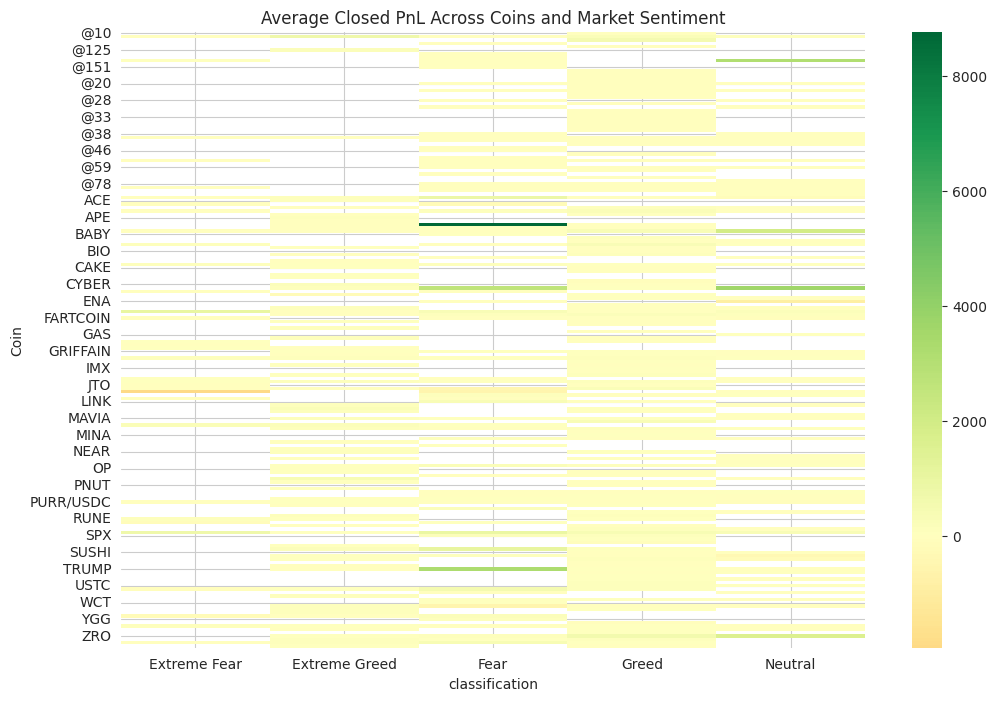

In [ ]:
heat = (
    merged.pivot_table(
        values="Closed PnL",
        index="Coin",
        columns="classification",
        aggfunc="mean"
    )
)

plt.figure(figsize=(12,8))

sns.heatmap(
    heat,
    cmap="RdYlGn",
    center=0
)

plt.title("Average Closed PnL Across Coins and Market Sentiment")

plt.show()

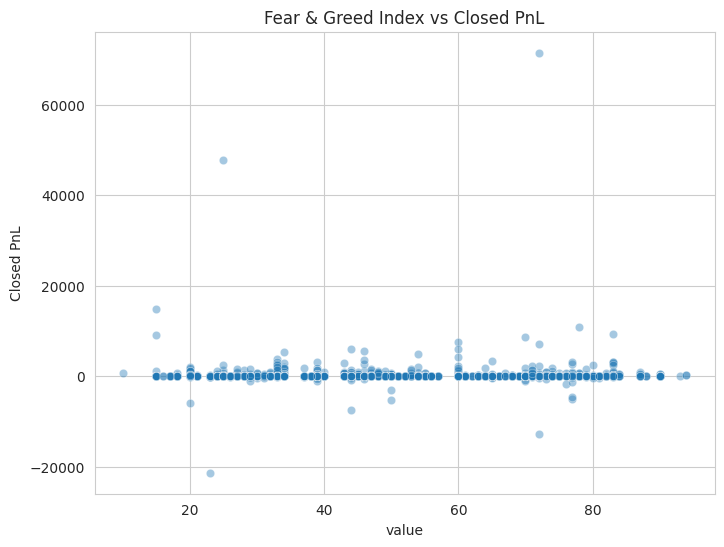

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged.sample(5000),
    x="value",
    y="Closed PnL",
    alpha=0.4
)

plt.title("Fear & Greed Index vs Closed PnL")

plt.show()


## Key Findings

- Successfully merged 83,798 historical trades with Bitcoin Fear & Greed Index data.
- Trader profitability varies significantly across different market sentiment categories.
- Extreme Greed recorded the highest average Closed PnL and win rate.
- The Fear & Greed Index shows a very weak linear correlation (r = 0.015) with Closed PnL.
- Kruskal-Wallis test confirmed statistically significant differences in profitability across sentiment groups (p < 0.001).
- Market sentiment influences trader behavior but is not a standalone predictor of trade profitability.

## Business Recommendations

- Use market sentiment as a contextual risk indicator rather than a direct trading signal.
- Combine sentiment with technical indicators and risk management.
- Adjust trading strategies based on prevailing market conditions.
- Develop trader-specific and asset-specific trading strategies.